# Final Project: Regression Tree Quant Model for Stock Return Prediction

**Features used (10 total):**
- 8 class features: marketcap, new_issue, investment, accruals, b2m, ret_2_12, CashFlow2TA, CashFlow2Prc
- **2 new features: ROE (Return on Equity), short_term_reversal (prior month return)**

In [ ]:
# Importing necessary Python libraries
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
from pandas import DateOffset

import sys
import os
import platform
import random
from math import sqrt, floor, ceil
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from multiprocessing import Process
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
import statsmodels.api as sm

In [ ]:
# # Connecting the Python code with the google drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/Project")


---
## Part 1: Data Loading & Feature Engineering
### 1A. Load and Clean CRSP Data

In [ ]:
#CRSP Data

# Importing CRSP price and returns datasets
Returns = pd.read_csv('CRSP_monthly_returns_1995_2024.csv.gz')

Returns['SHROUT_adj'] = Returns.SHROUT/Returns.CFACSHR  # Adjust shares outstanding for stock splits

# Handling missing values for PRC
Returns.PRC = abs(Returns.PRC)  # CRSP sets PRC negative if computed as bid-ask average

In [ ]:
# Market Cap calculation
Returns['marketcap'] = Returns.SHROUT * Returns.PRC
Returns['marketcap'] = Returns.groupby('PERMNO')['marketcap'].shift()  # Lagged market cap
Returns['marketcap'] = np.where(Returns['marketcap'] < 10000, np.nan, Returns['marketcap'])  # Exclude < $10M

# Exchange code filters
exch_nyse_amex_Nasdaq = ['N', 'Q', 'A']
Returns = Returns[Returns.PRIMEXCH.isin(exch_nyse_amex_Nasdaq)].copy()

# Keep only ordinary common shares
ord_common_shares = [10, 11, 12]
Returns = Returns[Returns.SHRCD.isin(ord_common_shares)].copy()

# Minor pre-processing
Returns.reset_index(inplace=True, drop=True)
Returns = Returns[["PERMNO","PRIMEXCH","date","RET","PRC","SHROUT","marketcap","SHROUT_adj"]].copy()
Returns.RET = pd.to_numeric(Returns.RET, errors='coerce')
Returns['PERMNO'] = Returns['PERMNO'].astype(int)
Returns.dropna(inplace=True)

Returns["date"] = pd.to_datetime(Returns["date"])
Returns["year"] = Returns["date"].dt.year
Returns["month"] = Returns["date"].dt.month

print(f"CRSP: {len(Returns)} rows, {Returns['PERMNO'].nunique()} unique stocks")
Returns.head()

CRSP: 2086037 rows, 20063 unique stocks


,PERMNO,PRIMEXCH,date,RET,PRC,SHROUT,marketcap,SHROUT_adj,year,month
6066,10001,Q,1990-02-28,-0.006289,9.87500,1022.0,10156.125,340.666667,1990,2
6068,10003,Q,1990-02-28,0.258065,9.75000,2194.0,17003.500,2194.000000,1990,2
6070,10007,Q,1990-02-28,-0.147826,3.06250,4120.0,14806.250,4120.000000,1990,2
6072,10010,Q,1990-02-28,0.277778,2.87500,6673.0,15014.250,4915.219281,1990,2
6073,10011,Q,1990-02-28,0.254386,4.46875,4458.0,15881.625,4458.000000,1990,2


### 1B. Load and Clean Compustat Data

In [ ]:
#Compustat data
Cstat = pd.read_csv('Compustat_characteristics_1995_2025.csv.gz')
Cstat.rename(columns={'LPERMNO': 'PERMNO'}, inplace=True)
Cstat = Cstat[["PERMNO","datadate","ceq","ib","oancf","at"]].copy()
Cstat['PERMNO'] = Cstat['PERMNO'].astype(int)
Cstat.reset_index(inplace=True, drop=True)

Cstat["datadate"] = pd.to_datetime(Cstat["datadate"])
Cstat['date'] = Cstat['datadate'].apply(lambda x: x + DateOffset(months=+5))  # 5-month lag to avoid look-ahead bias
Cstat.dropna(inplace=True)

print(f"Compustat: {len(Cstat)} rows")
Cstat.head()

Compustat: 195407 rows


,PERMNO,datadate,ceq,ib,oancf,at,date
0,54594,1990-05-31,189.548,25.655,19.371,388.521,1990-10-31
1,54594,1991-05-31,193.778,14.801,36.891,379.958,1991-10-31
2,54594,1992-05-31,196.737,10.020,8.814,395.351,1992-10-31
3,54594,1993-05-31,189.216,0.283,16.806,365.151,1993-10-31
4,54594,1994-05-31,189.488,9.484,6.697,417.626,1994-10-31


### 1C. Merge CRSP and Compustat

In [ ]:
Returns.sort_values(by='date', inplace=True)
Cstat.sort_values(by='date', inplace=True)
Cstat['lag_at'] = Cstat.groupby('PERMNO')['at'].shift()  # Prior fiscal year assets

merged_data = pd.merge_asof(Returns, Cstat, by='PERMNO', left_on='date', right_on='date',
                            tolerance=dt.timedelta(days=365))
merged_data.dropna(inplace=True)

print(f"Merged: {len(merged_data)} rows, {merged_data['PERMNO'].nunique()} unique stocks")
merged_data.head()

Merged: 1561961 rows, 15275 unique stocks


,PERMNO,PRIMEXCH,date,RET,PRC,SHROUT,marketcap,SHROUT_adj,year,month,datadate,ceq,ib,oancf,at,lag_at
63945,64902,Q,1991-05-31,-0.093750,7.250,8637.0,69096.00,8637.0,1991,5,1990-12-31,5.745,0.347,-0.497,20.956,20.610
64012,66086,Q,1991-05-31,-0.026316,9.250,2094.0,19893.00,1675.2,1991,5,1990-12-31,8.086,-0.658,5.389,34.982,36.826
64715,60177,N,1991-05-31,-0.142857,2.250,37850.0,99356.25,37850.0,1991,5,1990-12-31,65.139,-37.463,21.865,300.366,338.878
65078,78688,Q,1991-05-31,-0.125000,7.000,12700.0,101600.00,31750.0,1991,5,1990-12-31,22.539,-10.196,-7.308,35.829,44.550
65241,89122,Q,1991-05-31,0.065217,6.125,2604.0,14973.00,2604.0,1991,5,1990-12-31,6.870,0.631,0.796,7.908,7.735


### 1D. Compute Class Features (from L10_CreateStandardizedFeatures)

In [ ]:
# Feature: New Issue (net share issuance over 12 months)
merged_data['SHROUT_adj_lag12'] = merged_data.groupby('PERMNO')['SHROUT_adj'].shift(12)
merged_data['new_issue_asof_monthend'] = (merged_data['SHROUT_adj'] - merged_data['SHROUT_adj_lag12']) / merged_data['SHROUT_adj_lag12']
merged_data['new_issue'] = merged_data.groupby('PERMNO')['new_issue_asof_monthend'].shift()  # Lag to avoid look-ahead
merged_data.drop(columns=['SHROUT_adj_lag12', 'new_issue_asof_monthend'], inplace=True)

# Feature: Momentum (compounded returns from month t-12 to t-2)
merged_data['ret_2_12'] = 1
for i in range(2, 13):
    merged_data['ret_2_12'] = merged_data['ret_2_12'] * (1 + merged_data.groupby('PERMNO')['RET'].shift(i))

# Other features from class
merged_data['investment'] = merged_data['at'] / merged_data['lag_at'] - 1
merged_data['accruals'] = (merged_data['ib'] - merged_data['oancf']) / merged_data['at']
merged_data['b2m'] = merged_data.ceq / merged_data.marketcap
merged_data['CashFlow2TA'] = merged_data['oancf'] / merged_data['at']
merged_data['CashFlow2Prc'] = merged_data['oancf'] / merged_data['marketcap']

print("Class features computed: marketcap, new_issue, investment, accruals, b2m, ret_2_12, CashFlow2TA, CashFlow2Prc")

Class features computed: marketcap, new_issue, investment, accruals, b2m, ret_2_12, CashFlow2TA, CashFlow2Prc


---
## Question 1: New Features

We add **two new features** not used in class:

### Feature 1: ROE (Return on Equity) = `ib / ceq`
**Rationale:** ROE measures how efficiently a firm converts shareholders' equity into profit.
Higher ROE indicates stronger profitability and is a well-documented predictor of stock returns
(Fama-French profitability factor, Novy-Marx 2013). Unlike CashFlow2TA (cash flow / assets)
or CashFlow2Prc (cash flow / market cap), ROE uses *accrual earnings* scaled by *book equity*
rather than total assets or market cap, making it a distinct profitability signal.

### Feature 2: Short-Term Reversal = `RET(t-1)` (prior month return)
**Rationale:** Stocks that performed extremely well (poorly) last month tend to reverse the
following month, a well-documented anomaly (Jegadeesh 1990). This is purely a CRSP-based,
high-frequency signal — distinct from all the annual Compustat features and from the momentum
signal (ret_2_12), which deliberately *skips* the most recent month to avoid capturing this reversal.

In [ ]:

# NEW FEATURE 1: ROE (Return on Equity)
# = ib (income before extraordinary items) / ceq (book value of common equity)
# Note: ceq can be zero or negative for distressed firms -> produces inf/NaN.
# We handle this below with inf replacement + dropna.

merged_data['ROE'] = merged_data['ib'] / merged_data['ceq']

#  NEW FEATURE 2: Short-Term Reversal
# = prior month's return for each stock, i.e. RET shifted by 1 month.
# The shift ensures we only use information available before month t.
# This is distinct from momentum (ret_2_12) which covers months t-12 to t-2.

merged_data['short_term_reversal'] = merged_data.groupby('PERMNO')['RET'].shift(1)

print("New features computed: ROE, short_term_reversal")

New features computed: ROE, short_term_reversal


### 1E. Standardize Features (Percentile Ranking)

In [ ]:
# Updated full features
features = ['marketcap', 'new_issue', 'investment', 'accruals', 'b2m', 'ret_2_12',
            'CashFlow2TA', 'CashFlow2Prc', 'ROE', 'short_term_reversal']

# Replace inf/-inf with NaN before dropping.
# This is important for ROE: when ceq=0, ib/ceq = inf.
merged_data.replace([np.inf, -np.inf], np.nan, inplace=True)

merged_data.dropna(subset=features, how='any', inplace=True)
merged_data.reset_index(drop=True, inplace=True)

print(f"After cleaning: {len(merged_data)} rows, {merged_data['PERMNO'].nunique()} stocks")

After cleaning: 1375967 rows, 13170 stocks


In [ ]:
# Cross-sectional percentile ranking within each month
merged_data.set_index('date', inplace=True)
pct_rank_list = []

for sig in features:
    merged_data[sig + '_pct_rank'] = merged_data.groupby(level=0)[sig].rank(pct=True)
    pct_rank_list.append(sig + '_pct_rank')

# Output columns
out_list = pct_rank_list.copy()
add_on = ['RET', 'PERMNO']
out_list.extend(add_on)

print("Percentile-ranked features:")
print(pct_rank_list)
merged_data[out_list].head()

Percentile-ranked features:
['marketcap_pct_rank', 'new_issue_pct_rank', 'investment_pct_rank', 'accruals_pct_rank', 'b2m_pct_rank', 'ret_2_12_pct_rank', 'CashFlow2TA_pct_rank', 'CashFlow2Prc_pct_rank', 'ROE_pct_rank', 'short_term_reversal_pct_rank']


,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,ROE_pct_rank,short_term_reversal_pct_rank,RET,PERMNO
date,,,,,,,,,,,,
1992-06-30,0.750000,0.583333,0.250000,0.166667,0.083333,0.166667,0.416667,0.666667,0.916667,0.416667,-0.048781,75233
1992-06-30,0.666667,0.416667,0.166667,0.083333,0.250000,0.750000,0.750000,0.833333,0.083333,0.083333,-0.047619,60177
1992-06-30,0.833333,0.666667,0.916667,0.833333,0.500000,1.000000,0.583333,0.333333,0.583333,0.583333,0.040816,64902
1992-06-30,0.166667,0.333333,0.583333,0.250000,0.833333,0.333333,0.916667,1.000000,0.666667,0.500000,0.084746,66086
1992-06-30,0.583333,0.500000,0.083333,1.000000,0.416667,0.500000,0.083333,0.083333,0.166667,0.166667,-0.176471,78688


In [ ]:
# Save standardized features

merged_data[out_list].to_csv("standardizedFeatures.csv.gz")
print("Saved standardizedFeatures.csv.gz")


Saved standardizedFeatures.csv.gz


---
## Part 2: XGBoost Rolling-Window Prediction

In [ ]:
dat = pd.read_csv("standardizedFeatures.csv.gz")
print(f"Loaded: {len(dat)} rows, {dat['PERMNO'].nunique()} unique stocks")

Loaded: 1375967 rows, 13170 unique stocks


In [ ]:
# Data Pre-processing
dat["date"] = pd.to_datetime(dat["date"])
dat["yr"] = dat["date"].dt.year
dat = dat[dat['yr'] >= 1995]
dat["month"] = dat["date"].dt.month
dat.sort_values(by='date', inplace=True)
dat["month_num"] = (dat['date']).rank(method="dense")

# Adjusted Returns (target = stock return minus cross-sectional mean)
grouped = pd.DataFrame()
grouped["mean"] = dat.groupby('date').apply(lambda x: x["RET"].mean())
dat['mean_ret'] = dat['date'].map(grouped["mean"])
dat['adj_ret'] = dat['RET'] - dat['mean_ret']

#  Column list updated to includes ROE_pct_rank and short_term_reversal_pct_rank
dat = dat[['date', 'PERMNO', 'marketcap_pct_rank', 'new_issue_pct_rank',
           'investment_pct_rank', 'accruals_pct_rank', 'b2m_pct_rank',
           'ret_2_12_pct_rank', 'CashFlow2TA_pct_rank', 'CashFlow2Prc_pct_rank',
           'ROE_pct_rank', 'short_term_reversal_pct_rank',
           'RET', 'mean_ret', 'adj_ret', 'yr', 'month', 'month_num']]

print(f"Pre-processed data: {len(dat)} rows")
dat.head()

Pre-processed data: 1309350 rows


/tmp/ipykernel_15604/2740359397.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped["mean"] = dat.groupby('date').apply(lambda x: x["RET"].mean())


,date,PERMNO,marketcap_pct_rank,new_issue_pct_rank,investment_pct_rank,accruals_pct_rank,b2m_pct_rank,ret_2_12_pct_rank,CashFlow2TA_pct_rank,CashFlow2Prc_pct_rank,ROE_pct_rank,short_term_reversal_pct_rank,RET,mean_ret,adj_ret,yr,month,month_num
66617,1995-01-31,77730,0.863970,0.049252,0.751393,0.506889,0.773967,0.527998,0.637057,0.839930,0.678393,0.245089,0.135294,0.021175,0.114119,1995,1,1.0
68886,1995-01-31,60230,0.114922,0.603049,0.634418,0.934330,0.955438,0.506596,0.121079,0.040457,0.366168,0.425388,0.034483,0.021175,0.013308,1995,1,1.0
68887,1995-01-31,60206,0.851656,0.313691,0.352389,0.881266,0.489006,0.377602,0.291117,0.267077,0.628262,0.741425,-0.048872,0.021175,-0.070047,1995,1,1.0
68888,1995-01-31,60186,0.696863,0.943125,0.729112,0.935796,0.277338,0.593374,0.163882,0.168572,0.689241,0.278511,-0.043860,0.021175,-0.065035,1995,1,1.0
68889,1995-01-31,60169,0.605687,0.681032,0.576957,0.706831,0.552917,0.245969,0.383465,0.554090,0.635004,0.852243,-0.015385,0.021175,-0.036560,1995,1,1.0


In [ ]:
# Extract feature column names
y_column_name = 'adj_ret'
row_key_column_names = ['yyyymm', 'PERMNO', 'month', 'yr', 'month_num', 'RET', 'mean_ret', 'date']
feature_column_names = [x for x in dat.columns.values if (x not in row_key_column_names) & (x != y_column_name)]

print("Input signals/features:")
print(feature_column_names)

Input signals/features:
['marketcap_pct_rank', 'new_issue_pct_rank', 'investment_pct_rank', 'accruals_pct_rank', 'b2m_pct_rank', 'ret_2_12_pct_rank', 'CashFlow2TA_pct_rank', 'CashFlow2Prc_pct_rank', 'ROE_pct_rank', 'short_term_reversal_pct_rank']


In [ ]:
# XGBoost Regressor function
def xgboost_rolling(train_X, train_y, test_X, test_y):
    params = {
        'eval_metric': 'rmse', 'max_depth': 4, 'min_child_weight': 1,
        'gamma': 0.2, 'subsample': 1.0, 'colsample_bytree': 0.8,
        'alpha': 0, 'lambda': 1, 'learning_rate': 0.3, 'seed': 0
    }
    regressor_main = xgb.XGBRegressor(**params)
    regressor_main.fit(train_X, train_y)
    prediction = regressor_main.predict(test_X)
    R2_score = regressor_main.score(test_X, test_y)
    return prediction, R2_score, regressor_main

In [ ]:
## XGBoost Rolling-Window Training

predicted_ret_df = pd.DataFrame()
rolling_window = 60  # 60-month (5-year) training window
start_month_limit = int(dat["month_num"].max()) - rolling_window

for t in range(1, start_month_limit):
    if t % 10 == 0:
        print(t)

    train_month_start = t
    train_month_end = train_month_start + rolling_window
    y_column_name = 'adj_ret'
    reg_factors = feature_column_names

    # Training and test split
    train_dat = dat[(dat['month_num'] <= train_month_end) & (dat['month_num'] >= train_month_start)]
    test_dat = dat[(dat['month_num'] == train_month_end + 1)]
    train_X = train_dat[reg_factors]
    test_X = test_dat[reg_factors]
    train_y = train_dat[y_column_name]
    test_y = test_dat[y_column_name]
    output_df = xgboost_rolling(train_X, train_y, test_X, test_y)

    # Store predictions
    test_dat = dat[(dat['month_num'] == train_month_end + 1)].copy()
    test_dat.loc[:, "predicted_adj_ret"] = output_df[0]
    test_dat.rename(columns={"adj_ret": "actual_adj_ret"}, inplace=True)
    test_dat = test_dat[["PERMNO", "yr", "month", "predicted_adj_ret", "actual_adj_ret", "RET"]]
    predicted_ret_df = pd.concat([predicted_ret_df, test_dat], axis=0)

predicted_ret_df.to_csv("rolling_xgb_pred_returns.csv", index=False)
print(f"\nDone. Predictions saved: {len(predicted_ret_df)} rows")

10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290

Done. Predictions saved: 1066373 rows


### Tree Visualization

In [ ]:
# Extract and display tree structure from the last trained model
model = output_df[2]
tree_df = model.get_booster().trees_to_dataframe()
del tree_df["Category"]
tree_df[tree_df["Tree"] == 0]

,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover
0,0,0,0-0,CashFlow2Prc_pct_rank,0.988145,0-1,0-2,0-2,4.985013,206261.0
1,0,1,0-1,CashFlow2TA_pct_rank,0.121278,0-3,0-4,0-4,3.339266,203784.0
2,0,2,0-2,short_term_reversal_pct_rank,0.004032,0-5,0-6,0-6,43.579941,2477.0
3,0,3,0-3,accruals_pct_rank,0.062650,0-7,0-8,0-8,1.931931,24985.0
4,0,4,0-4,CashFlow2Prc_pct_rank,0.820109,0-9,0-10,0-10,1.558280,178799.0
5,0,5,0-5,ROE_pct_rank,0.109597,0-11,0-12,0-12,46.996448,43.0
6,0,6,0-6,ret_2_12_pct_rank,0.035304,0-13,0-14,0-14,1.364074,2434.0
7,0,7,0-7,ret_2_12_pct_rank,0.027479,0-15,0-16,0-16,1.555076,4961.0
8,0,8,0-8,investment_pct_rank,0.218913,0-17,0-18,0-18,2.076356,20024.0
9,0,9,0-9,CashFlow2Prc_pct_rank,0.046970,0-19,0-20,0-20,1.639541,144143.0


/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


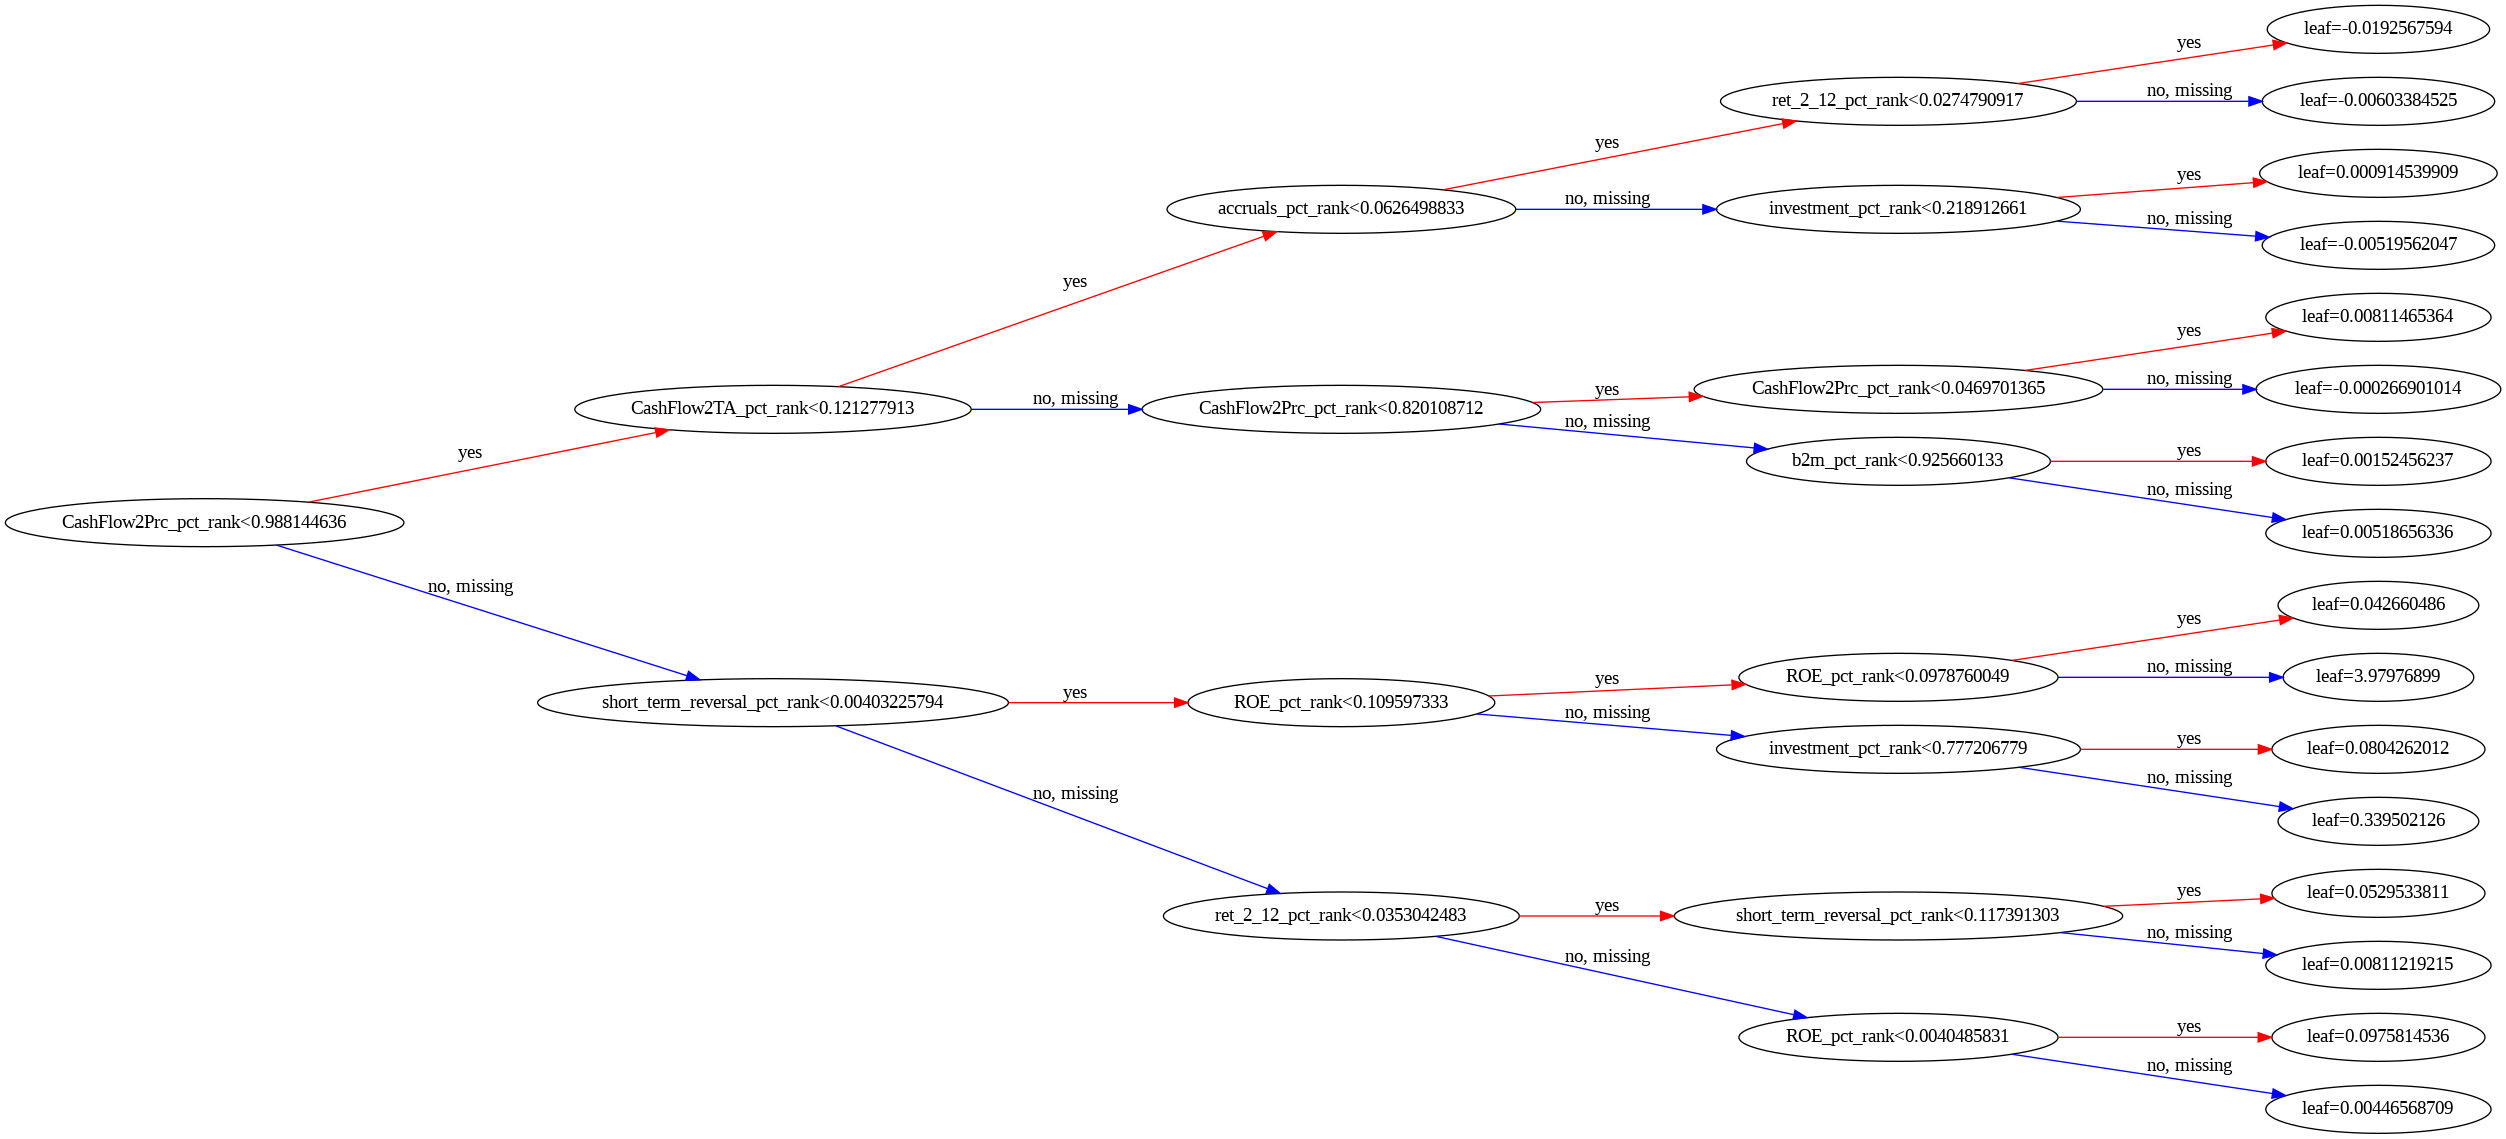

In [ ]:
# Plot a sample XGBoost tree
from xgboost import to_graphviz
import graphviz
from IPython.display import Image

graph = to_graphviz(model, num_trees=0, rankdir='LR')
file_path = graph.render('xgboost_tree', format='png')
Image(filename=file_path)

Feature Importance

<Figure size 1000x600 with 0 Axes>

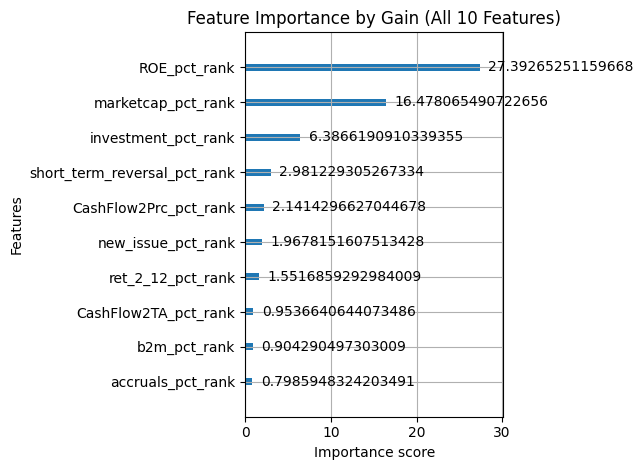

In [ ]:

plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=12, importance_type='gain')
plt.title("Feature Importance by Gain (All 10 Features)")
plt.tight_layout()
plt.show()

---
## Question 2: Decile Portfolio Returns

Stocks are sorted into 10 equal-sized groups (deciles) each month based on predicted adjusted return.
Decile 0 = lowest predicted return, Decile 9 = highest. The **diff portfolio** is long Decile 9 minus short Decile 0.

In [ ]:
predicted_ret_df = pd.read_csv("rolling_xgb_pred_returns.csv")

In [ ]:

predicted_ret_df['rank_order'] = predicted_ret_df.groupby(['yr', 'month'])['predicted_adj_ret'] \
                                           .rank(method='first')

predicted_ret_df['rank'] = predicted_ret_df.groupby(['yr', 'month'])['rank_order'] \
                                             .transform(lambda x: pd.qcut(x, 10, labels=False))
predicted_ret_df.reset_index(inplace=True, drop=True)

print(f"Decile assignments complete: {len(predicted_ret_df)} stock-months")
predicted_ret_df.head()

Decile assignments complete: 1066373 stock-months


,PERMNO,yr,month,predicted_adj_ret,actual_adj_ret,RET,rank_order,rank
0,77757,2000,2,0.007922,-0.189845,-0.047170,3348.0,8
1,77763,2000,2,0.013315,-0.098427,0.044248,3623.0,8
2,77854,2000,2,-0.003647,-0.318114,-0.175439,1468.0,3
3,77862,2000,2,0.006332,-0.260955,-0.118280,3217.0,7
4,78050,2000,2,-0.003995,-0.197297,-0.054622,1391.0,3


In [ ]:
# Filter evaluation period
predicted_ret_df_2000 = predicted_ret_df[predicted_ret_df['yr'] >= 2000].copy()
print(f"Evaluation period: yr >= 2000, {len(predicted_ret_df_2000)} stock-months")

Evaluation period: yr >= 2000, 1066373 stock-months


In [ ]:
# Monthly Mean Portfolio Returns by Decile
meanret = predicted_ret_df_2000.groupby(['yr', 'month', 'rank'])['RET'].mean().to_frame()
meanret = meanret.unstack(level=-1).copy()
meanret[('RET', 'diff')] = meanret[('RET', 9)] - meanret[('RET', 0)]  # Long-short portfolio

nmon = len(meanret)  # Number of months
meanret = meanret.stack(level=-1, future_stack=True).copy()

# Summary statistics
global_mean = meanret.groupby('rank')['RET'].agg(["mean", "std"])
global_mean['t-stat'] = np.sqrt(nmon - 1) * global_mean['mean'] / global_mean['std']

print("="*70)
print("ANSWER TO QUESTION 2: Decile Portfolio Returns")
print("="*70)
print(f"Evaluation period: 2000 onwards ({nmon} months)")
print(f"Decile 0 = lowest predicted return, Decile 9 = highest")
print(f"diff = Decile 9 (long) minus Decile 0 (short)")
print("="*70)
global_mean[['mean', 'std', 't-stat']]

ANSWER TO QUESTION 2: Decile Portfolio Returns
Evaluation period: 2000 onwards (299 months)
Decile 0 = lowest predicted return, Decile 9 = highest
diff = Decile 9 (long) minus Decile 0 (short)


,mean,std,t-stat
rank,,,
0,0.001692,0.093359,0.312877
1,0.007196,0.072841,1.705343
2,0.008960,0.064038,2.415288
3,0.010247,0.057207,3.092242
4,0.010779,0.054841,3.393059
5,0.010327,0.054647,3.262164
6,0.010834,0.055095,3.394484
7,0.011125,0.056220,3.416069
8,0.012043,0.062376,3.332845


/tmp/ipykernel_15604/539470739.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rank', y='mean', data=global_mean_plot, palette='viridis')


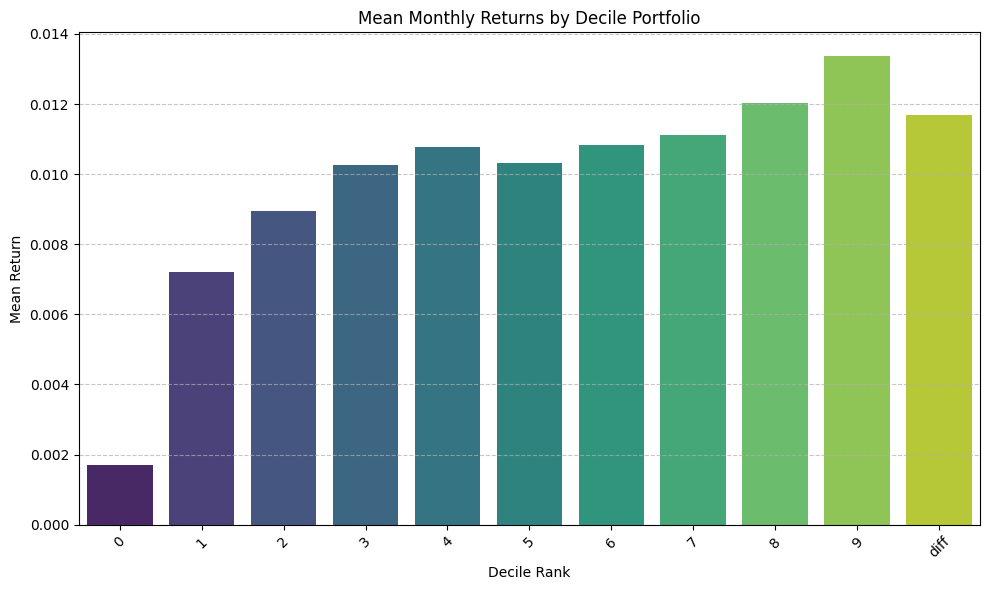

In [ ]:
# Bar chart of mean returns by decile
global_mean_plot = global_mean.reset_index()
global_mean_plot['rank'] = global_mean_plot['rank'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(x='rank', y='mean', data=global_mean_plot, palette='viridis')
plt.title('Mean Monthly Returns by Decile Portfolio')
plt.xlabel('Decile Rank')
plt.ylabel('Mean Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Question 3: Performance Metrics

We report: mean monthly return, standard deviation, t-statistic, annualized return,
annualized volatility, Sharpe ratio, and maximum drawdown for the diff portfolio.

In [ ]:

perf = global_mean.copy()
perf['ann_return'] = perf['mean'] * 12
perf['ann_vol'] = perf['std'] * np.sqrt(12)
perf['sharpe'] = perf['ann_return'] / perf['ann_vol']

# Max Drawdown for the diff portfolio
diff_series = meanret[meanret.index.get_level_values('rank') == 'diff']['RET'].dropna()
cumval = (1 + diff_series).cumprod()
max_dd = ((cumval - cumval.cummax()) / cumval.cummax()).min()

print("="*70)
print("ANSWER TO QUESTION 3: Performance Metrics")
print("="*70)
print(perf[['mean', 'std', 't-stat', 'ann_return', 'ann_vol', 'sharpe']].round(4).to_string())
print(f"\nDiff Portfolio Maximum Drawdown: {max_dd:.4f}")
print("="*70)

ANSWER TO QUESTION 3: Performance Metrics
        mean     std  t-stat  ann_return  ann_vol  sharpe
rank                                                     
0     0.0017  0.0934  0.3129      0.0203   0.3234  0.0628
1     0.0072  0.0728  1.7053      0.0863   0.2523  0.3422
2     0.0090  0.0640  2.4153      0.1075   0.2218  0.4847
3     0.0102  0.0572  3.0922      0.1230   0.1982  0.6205
4     0.0108  0.0548  3.3931      0.1294   0.1900  0.6809
5     0.0103  0.0546  3.2622      0.1239   0.1893  0.6546
6     0.0108  0.0551  3.3945      0.1300   0.1909  0.6812
7     0.0111  0.0562  3.4161      0.1335   0.1948  0.6855
8     0.0120  0.0624  3.3328      0.1445   0.2161  0.6688
9     0.0134  0.0778  2.9693      0.1605   0.2694  0.5959
diff  0.0117  0.0544  3.7059      0.1402   0.1885  0.7437

Diff Portfolio Maximum Drawdown: -0.3389


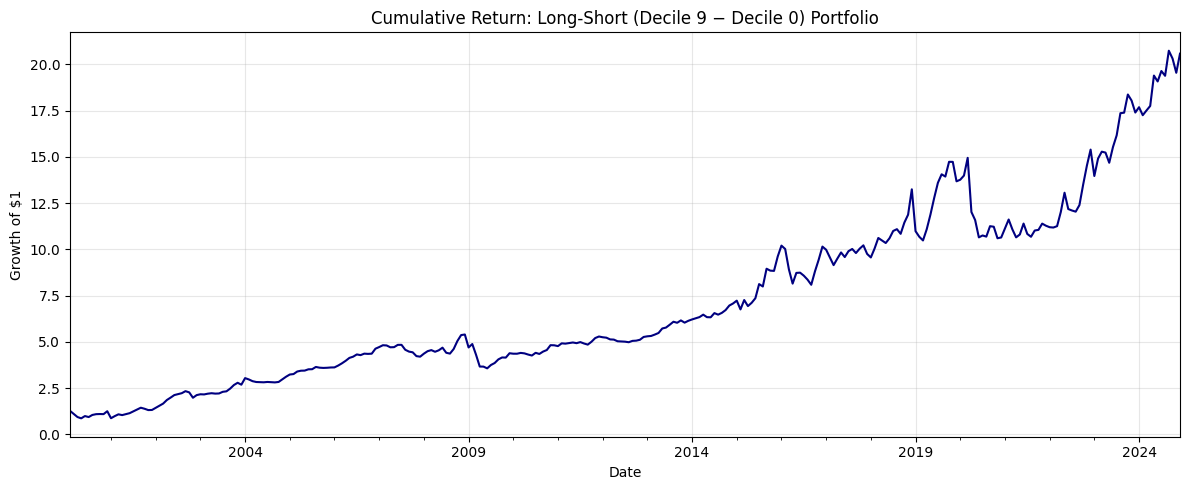

In [ ]:

diff_monthly = meanret[meanret.index.get_level_values('rank') == 'diff']['RET'].copy()
diff_monthly = diff_monthly.reset_index()
diff_monthly['date'] = pd.to_datetime(dict(year=diff_monthly['yr'], month=diff_monthly['month'], day=1))
diff_monthly = diff_monthly.set_index('date').sort_index()

cumulative_diff = (1 + diff_monthly['RET']).cumprod()

plt.figure(figsize=(12, 5))
cumulative_diff.plot(color='navy', linewidth=1.5)
plt.title('Cumulative Return: Long-Short (Decile 9 − Decile 0) Portfolio')
plt.ylabel('Growth of $1')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Question 4: Is the Long-Short Portfolio Market-Neutral?

To test market neutrality, we regress the diff portfolio's monthly returns on the market
excess return (Mkt-RF from Fama-French). If the market beta is close to zero and not
statistically significant, the portfolio is approximately market-neutral.

In [ ]:
# Download Fama-French factors
import requests, zipfile, io

url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
fname = z.namelist()[0]

ff_raw = pd.read_csv(z.open(fname), skiprows=3, header=0)
ff_raw.columns = ['date', 'Mkt-RF', 'SMB', 'HML', 'RF']
ff_raw = ff_raw[ff_raw['date'].astype(str).str.strip().str.match(r'^\d{6}$')].copy()
ff_raw['date'] = pd.to_datetime(ff_raw['date'].astype(str).str.strip(), format='%Y%m')
ff_raw[['Mkt-RF', 'SMB', 'HML', 'RF']] = ff_raw[['Mkt-RF', 'SMB', 'HML', 'RF']].astype(float) / 100
ff_raw = ff_raw.set_index('date')

print(f"Fama-French data: {len(ff_raw)} months")
ff_raw.tail()

Fama-French data: 1196 months


,Mkt-RF,SMB,HML,RF
date,,,,
2025-10-01,0.0196,-0.0055,-0.0310,0.0037
2025-11-01,-0.0013,0.0038,0.0376,0.0030
2025-12-01,-0.0036,-0.0106,0.0242,0.0034
2026-01-01,0.0102,0.0220,0.0372,0.0030
2026-02-01,-0.0117,0.0014,0.0283,0.0028


In [ ]:
# Merge diff portfolio returns with Fama-French market factor
diff_for_reg = diff_monthly['RET'].copy()
diff_for_reg.index = pd.to_datetime(diff_for_reg.index).to_period('M').to_timestamp()

df_reg = diff_for_reg.to_frame(name='diff').join(ff_raw[['Mkt-RF', 'RF']], how='inner')
df_reg = df_reg.dropna()
print(f"Regression sample: {len(df_reg)} months")

Regression sample: 299 months


In [ ]:
# OLS Regression: diff returns = alpha + beta * Mkt-RF + epsilon
X = sm.add_constant(df_reg['Mkt-RF'])
y = df_reg['diff']
result = sm.OLS(y, X).fit()

print(result.summary())

print("\n" + "="*70)
print("ANSWER TO QUESTION 4: Market Neutrality Test")
print("="*70)
print(f"Market Beta:  {result.params['Mkt-RF']:.4f}  (p-value: {result.pvalues['Mkt-RF']:.4f})")
print(f"Alpha:        {result.params['const']:.4f}  (p-value: {result.pvalues['const']:.4f})")
print(f"R-squared:    {result.rsquared:.4f}")
print()

if result.pvalues['Mkt-RF'] > 0.05:
    print("Conclusion: The market beta is NOT statistically significant at the 5% level.")
    print("The long-short portfolio is approximately market-neutral.")
else:
    print(f"Conclusion: The market beta ({result.params['Mkt-RF']:.4f}) is statistically significant.")
    print("The long-short portfolio has some market exposure and is not perfectly market-neutral.")

if result.pvalues['const'] < 0.05:
    print(f"\nThe alpha ({result.params['const']:.4f} monthly) is statistically significant,")
    print("indicating the strategy generates returns beyond market exposure.")
print("="*70)

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     24.47
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.27e-06
Time:                        22:01:34   Log-Likelihood:                 458.45
No. Observations:                 299   AIC:                            -912.9
Df Residuals:                     297   BIC:                            -905.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0137      0.003      4.479      0.0

---
## Question 5: Addressing Outliers

Outliers in raw financial data (e.g., extreme earnings spikes, tiny book equity producing
enormous ROE, data errors) can distort tree splits and inflate/deflate portfolio returns.
Our model addresses outliers in **three ways**:

1. **Percentile Ranking:** All features are converted to cross-sectional percentile ranks
   each month, mapping every value to [0, 1] regardless of magnitude. A stock with
   absurdly high ROE (e.g., due to near-zero equity) gets ranked at ~1.0 rather than
   dominating the regression. This completely neutralizes the influence of extreme raw
   values on model inputs.

2. **Inf/NaN Removal:** We explicitly replace inf/-inf with NaN and drop affected rows,
   preventing divide-by-zero artifacts (e.g., from ROE when ceq ≈ 0, or b2m when
   marketcap is tiny) from entering the model.

3. **Market Cap Floor:** Stocks with market capitalization below $10M are excluded.
   Micro-cap stocks are disproportionately prone to data errors, extreme returns, and
   illiquidity — removing them reduces noise in both features and target returns.

Additionally, **XGBoost's tree-based structure is inherently more robust to outliers**
than linear models. Trees partition data using binary splits rather than fitting a line
that extreme points can pull, so even if a residual outlier makes it through, it has
limited impact on the model's predictions.